Wellness 데이터 분석 중... 잠시만 기다려주세요.
Chatbot 데이터 분석 중... 잠시만 기다려주세요.
Subject 데이터 분석 중... 잠시만 기다려주세요.


C:\Users\user\AppData\Local\Temp\ipykernel_4836\3688802534.py:92: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4836\3688802534.py:92: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4836\3688802534.py:92: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4836\3688802534.py:92: UserWarning: Glyph 49483 (\N{HANGUL SYLLABLE SES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4836\3688802534.py:92: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4836\3688802534.py:92: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users

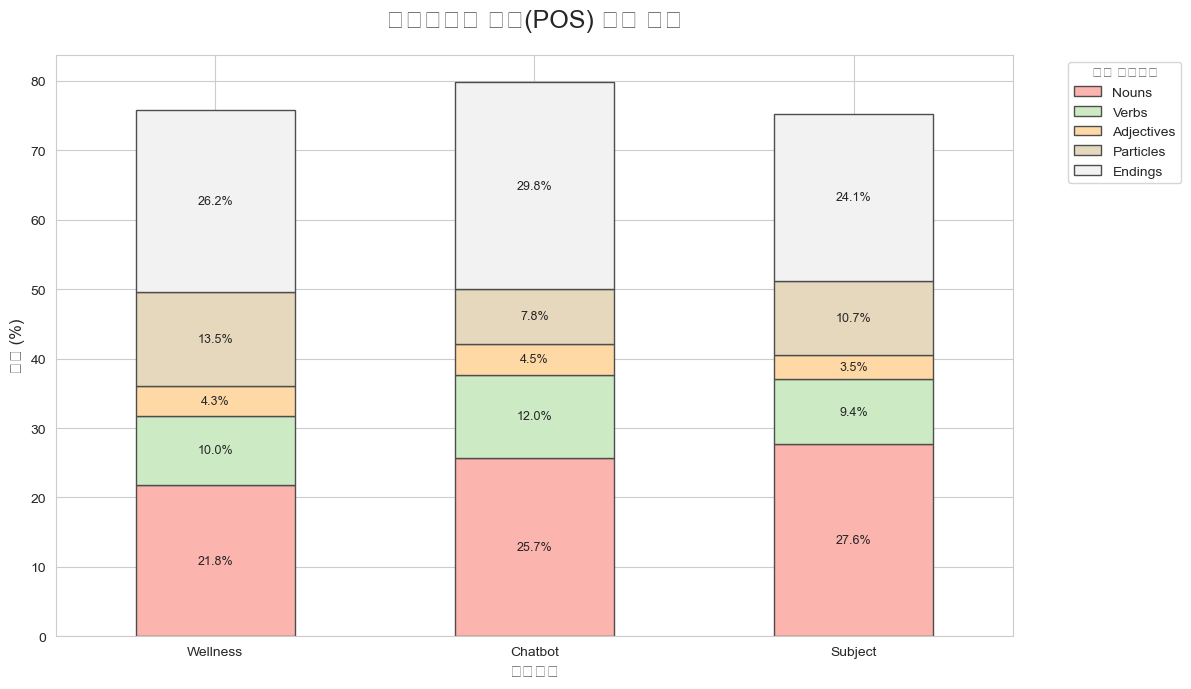

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kiwipiepy import Kiwi
from collections import Counter

import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (윈도우 기준)
plt.rc('font', family='Malgun Gothic')

# 2. 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

# (선택) 그래프 글자를 더 선명하게 보고 싶다면
%config InlineBackend.figure_format = 'retina'

# 1. Kiwi 초기화 및 데이터 로드
kiwi = Kiwi()
files = {
    "Wellness": "cleaned_wellness.csv",
    "Chatbot": "cleaned_chatbot.csv",
    "Subject": "cleaned_subject.csv"
}

def analyze_pos_ratio_fixed(df, name, column_name='utterance'):
    # 데이터를 리스트로 변환하고 결측치 제거
    sentences = df[column_name].dropna().astype(str).tolist()
    pos_counts = Counter()
    total_tokens = 0

    print(f"{name} 데이터 분석 중... 잠시만 기다려주세요.")

    # [수정 핵심] pipe 대신 모든 버전에서 작동하는 analyze 사용
    for sent in sentences:
        if not sent.strip(): continue # 빈 문장 건너뛰기
        
        # 형태소 분석 수행
        result = kiwi.analyze(sent)
        
        # result[0][0]은 가장 확률이 높은 분석 결과의 토큰 리스트입니다.
        for token in result[0][0]:
            tag = token.tag
            total_tokens += 1
            
            # 품사 카테고리 분류
            if tag.startswith('N'): # 명사
                pos_counts['Nouns'] += 1
            elif tag == 'VV': # 동사
                pos_counts['Verbs'] += 1
            elif tag == 'VA': # 형용사
                pos_counts['Adjectives'] += 1
            elif tag.startswith('J'): # 조사
                pos_counts['Particles'] += 1
            elif tag.startswith('E'): # 어미
                pos_counts['Endings'] += 1
            else:
                pos_counts['Others'] += 1

    # 비율(%) 계산
    if total_tokens == 0: return None
    ratios = {category: (count / total_tokens) * 100 for category, count in pos_counts.items()}
    ratios['Dataset'] = name
    return ratios

# 2. 분석 실행
all_ratios = []
for name, file in files.items():
    try:
        df = pd.read_csv(file)
        res = analyze_pos_ratio_fixed(df, name)
        if res: all_ratios.append(res)
    except Exception as e:
        print(f"{name} 처리 중 오류 발생: {e}")

# 3. 데이터프레임 정리 및 시각화
ratio_df = pd.DataFrame(all_ratios).set_index('Dataset')
# 주요 품사만 선택하여 시각화 (Others 제외 가능)
plot_df = ratio_df[['Nouns', 'Verbs', 'Adjectives', 'Particles', 'Endings']]

# 한글 폰트 설정 (윈도우 기준)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 시각화
sns.set_style("whitegrid")
ax = plot_df.plot(kind='bar', stacked=True, figsize=(12, 7), 
                  colormap='Pastel1', edgecolor='0.3')

plt.title('데이터셋별 품사(POS) 분포 비교', fontsize=18, pad=20)
plt.ylabel('비율 (%)', fontsize=12)
plt.xlabel('데이터셋', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='품사 카테고리', bbox_to_anchor=(1.05, 1), loc='upper left')

# 수치 표시
for p in ax.patches:
    h = p.get_height()
    if h > 3: # 3% 이상일 때만 텍스트 표시
        ax.text(p.get_x() + p.get_width()/2., p.get_y() + h/2., 
                f'{h:.1f}%', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Wellness 데이터 분석 중... 잠시만 기다려주세요.
Chatbot 데이터 분석 중... 잠시만 기다려주세요.
Subject 데이터 분석 중... 잠시만 기다려주세요.


C:\Users\user\AppData\Local\Temp\ipykernel_4836\78211950.py:103: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4836\78211950.py:103: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4836\78211950.py:103: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4836\78211950.py:103: UserWarning: Glyph 49483 (\N{HANGUL SYLLABLE SES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4836\78211950.py:103: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4836\78211950.py:103: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\

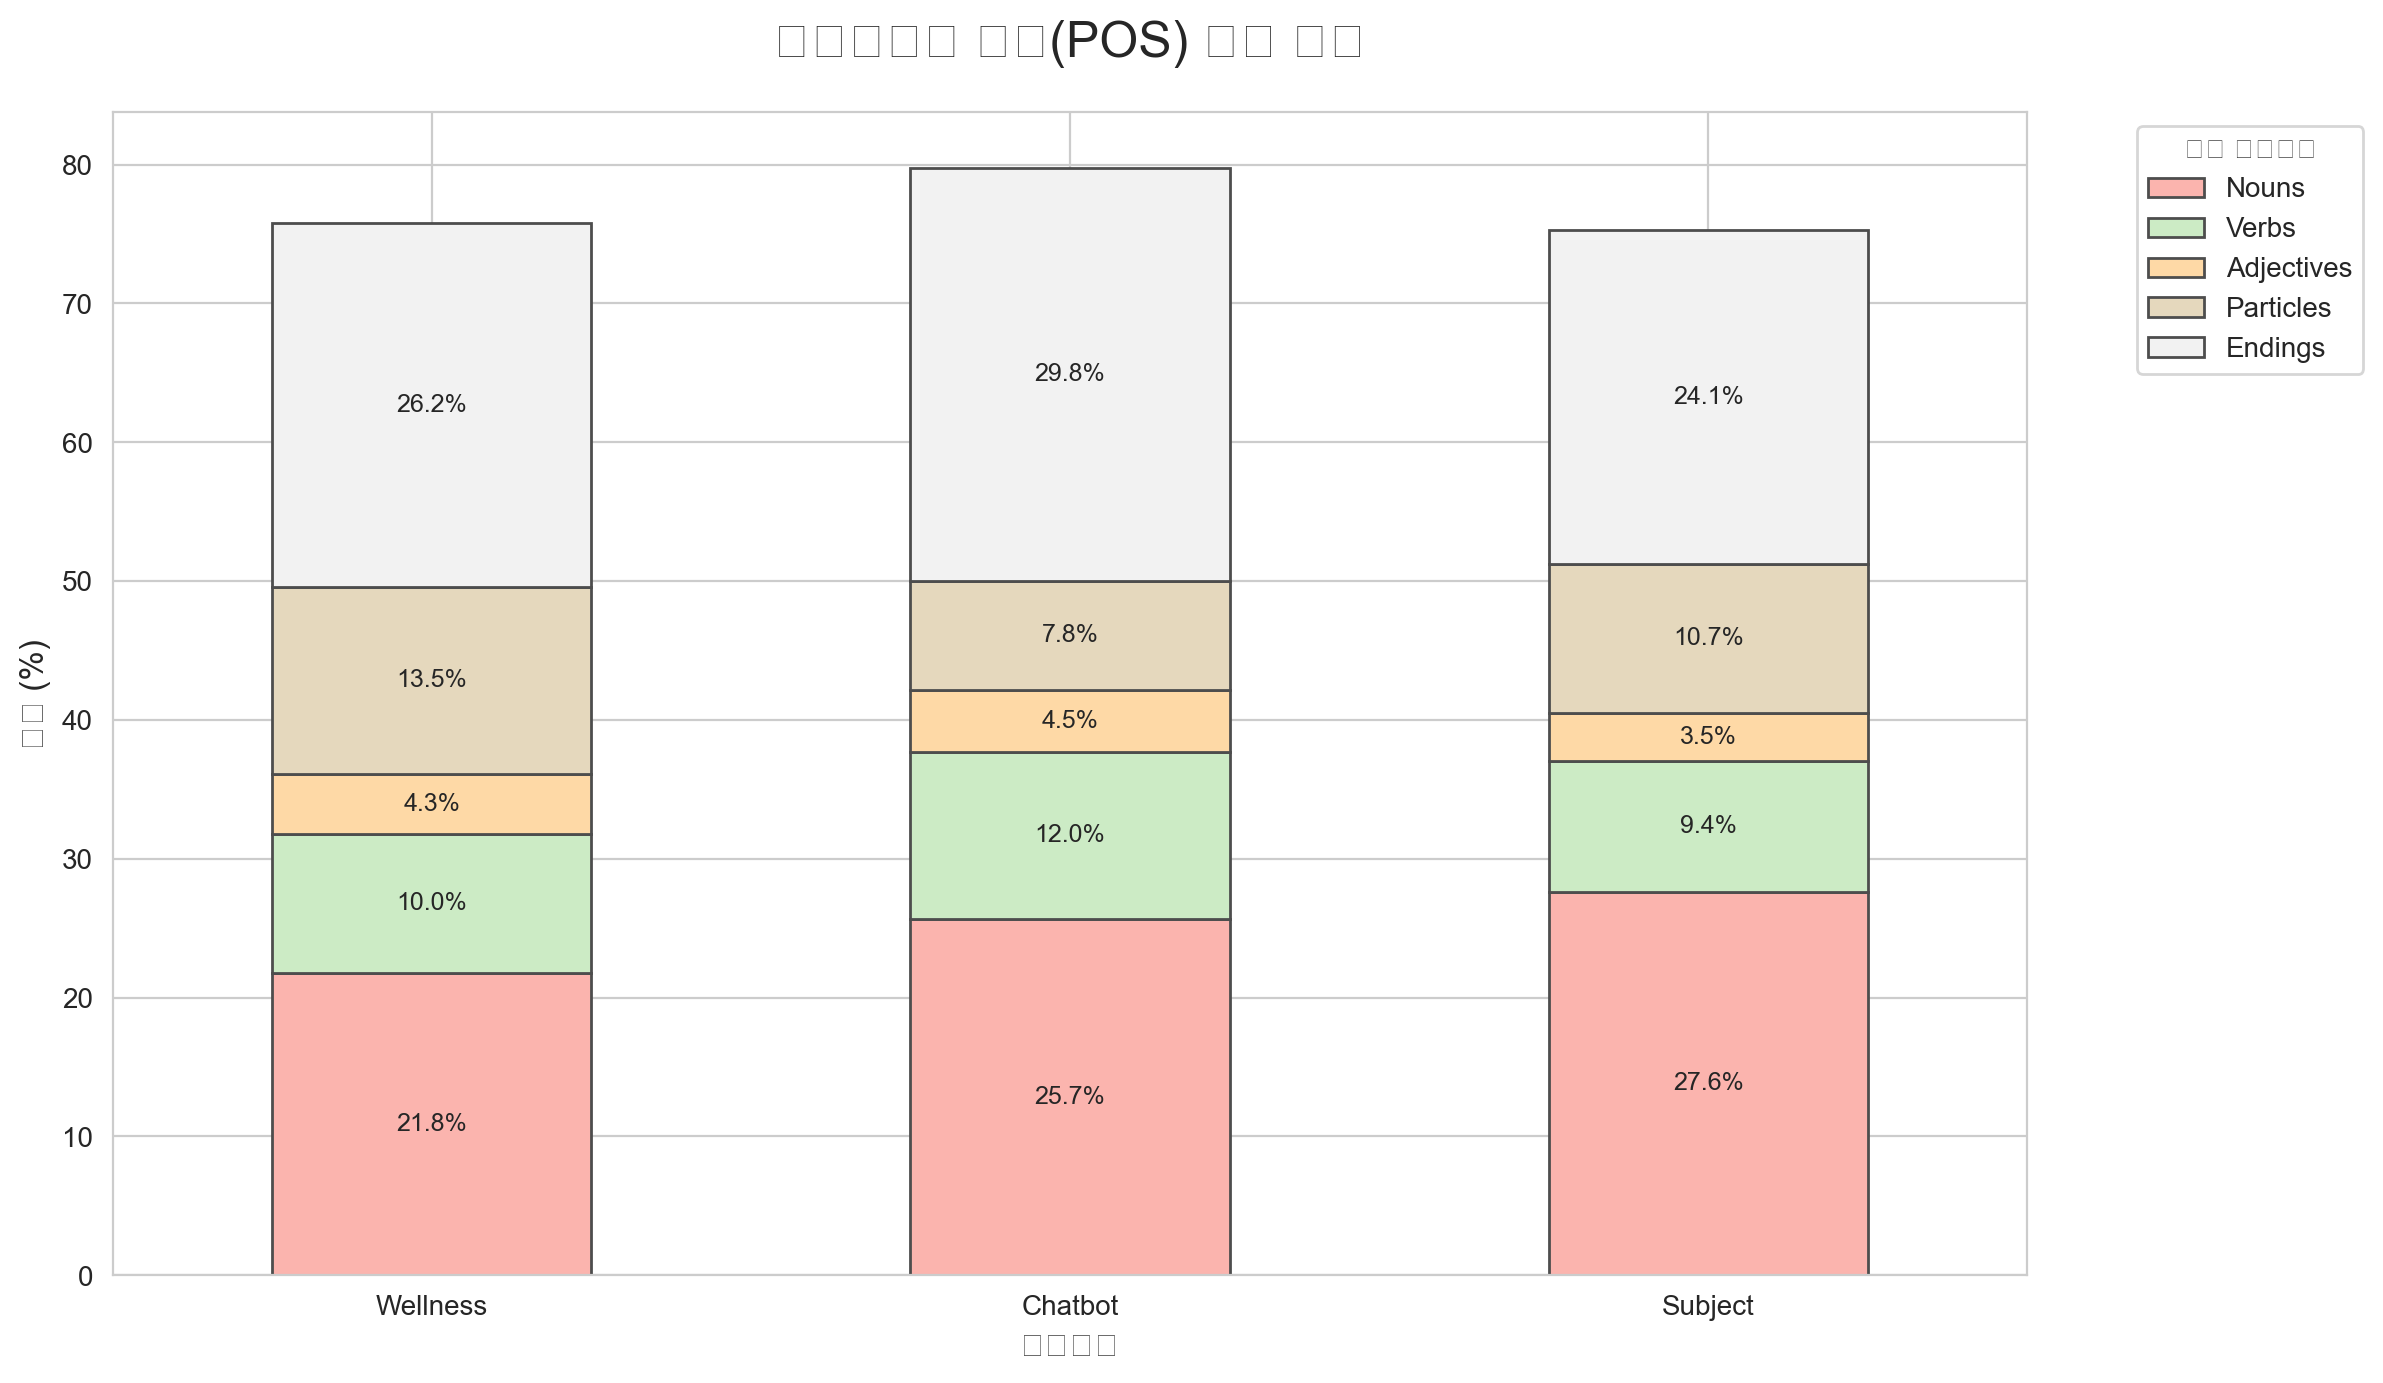

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kiwipiepy import Kiwi
from collections import Counter

import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (윈도우 기준)
plt.rc('font', family='Malgun Gothic')

# 2. 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

# (선택) 그래프 글자를 더 선명하게 보고 싶다면
%config InlineBackend.figure_format = 'retina'

# 1. Kiwi 초기화 및 데이터 로드
kiwi = Kiwi()
files = {
    "Wellness": "cleaned_wellness.csv",
    "Chatbot": "cleaned_chatbot.csv",
    "Subject": "cleaned_subject.csv"
}

def analyze_pos_ratio_fixed(df, name, column_name='utterance'):
    # 데이터를 리스트로 변환하고 결측치 제거
    sentences = df[column_name].dropna().astype(str).tolist()
    pos_counts = Counter()
    total_tokens = 0

    print(f"{name} 데이터 분석 중... 잠시만 기다려주세요.")

    # [수정 핵심] pipe 대신 모든 버전에서 작동하는 analyze 사용
    for sent in sentences:
        if not sent.strip(): continue # 빈 문장 건너뛰기
        
        # 형태소 분석 수행
        result = kiwi.analyze(sent)
        
        # result[0][0]은 가장 확률이 높은 분석 결과의 토큰 리스트입니다.
        for token in result[0][0]:
            tag = token.tag
            total_tokens += 1
            
            # 품사 카테고리 분류
            if tag.startswith('N'): # 명사
                pos_counts['Nouns'] += 1
            elif tag == 'VV': # 동사
                pos_counts['Verbs'] += 1
            elif tag == 'VA': # 형용사
                pos_counts['Adjectives'] += 1
            elif tag.startswith('J'): # 조사
                pos_counts['Particles'] += 1
            elif tag.startswith('E'): # 어미
                pos_counts['Endings'] += 1
            else:
                pos_counts['Others'] += 1

    # 비율(%) 계산
    if total_tokens == 0: return None
    ratios = {category: (count / total_tokens) * 100 for category, count in pos_counts.items()}
    ratios['Dataset'] = name
    return ratios

# 2. 분석 실행
all_ratios = []
for name, file in files.items():
    try:
        df = pd.read_csv(file)
        res = analyze_pos_ratio_fixed(df, name)
        if res: all_ratios.append(res)
    except Exception as e:
        print(f"{name} 처리 중 오류 발생: {e}")

# 3. 데이터프레임 정리 및 시각화
ratio_df = pd.DataFrame(all_ratios).set_index('Dataset')
# 주요 품사만 선택하여 시각화 (Others 제외 가능)
plot_df = ratio_df[['Nouns', 'Verbs', 'Adjectives', 'Particles', 'Endings']]

# 한글 폰트 설정 (윈도우 기준)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 시각화
sns.set_style("whitegrid")
ax = plot_df.plot(kind='bar', stacked=True, figsize=(12, 7), 
                  colormap='Pastel1', edgecolor='0.3')

plt.title('데이터셋별 품사(POS) 분포 비교', fontsize=18, pad=20)
plt.ylabel('비율 (%)', fontsize=12)
plt.xlabel('데이터셋', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='품사 카테고리', bbox_to_anchor=(1.05, 1), loc='upper left')

# 수치 표시
for p in ax.patches:
    h = p.get_height()
    if h > 3: # 3% 이상일 때만 텍스트 표시
        ax.text(p.get_x() + p.get_width()/2., p.get_y() + h/2., 
                f'{h:.1f}%', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

시스템 폰트 설정 완료: Malgun Gothic
[Wellness] 데이터 분석 중... 잠시만 기다려주세요.
[Chatbot] 데이터 분석 중... 잠시만 기다려주세요.
[Subject] 데이터 분석 중... 잠시만 기다려주세요.


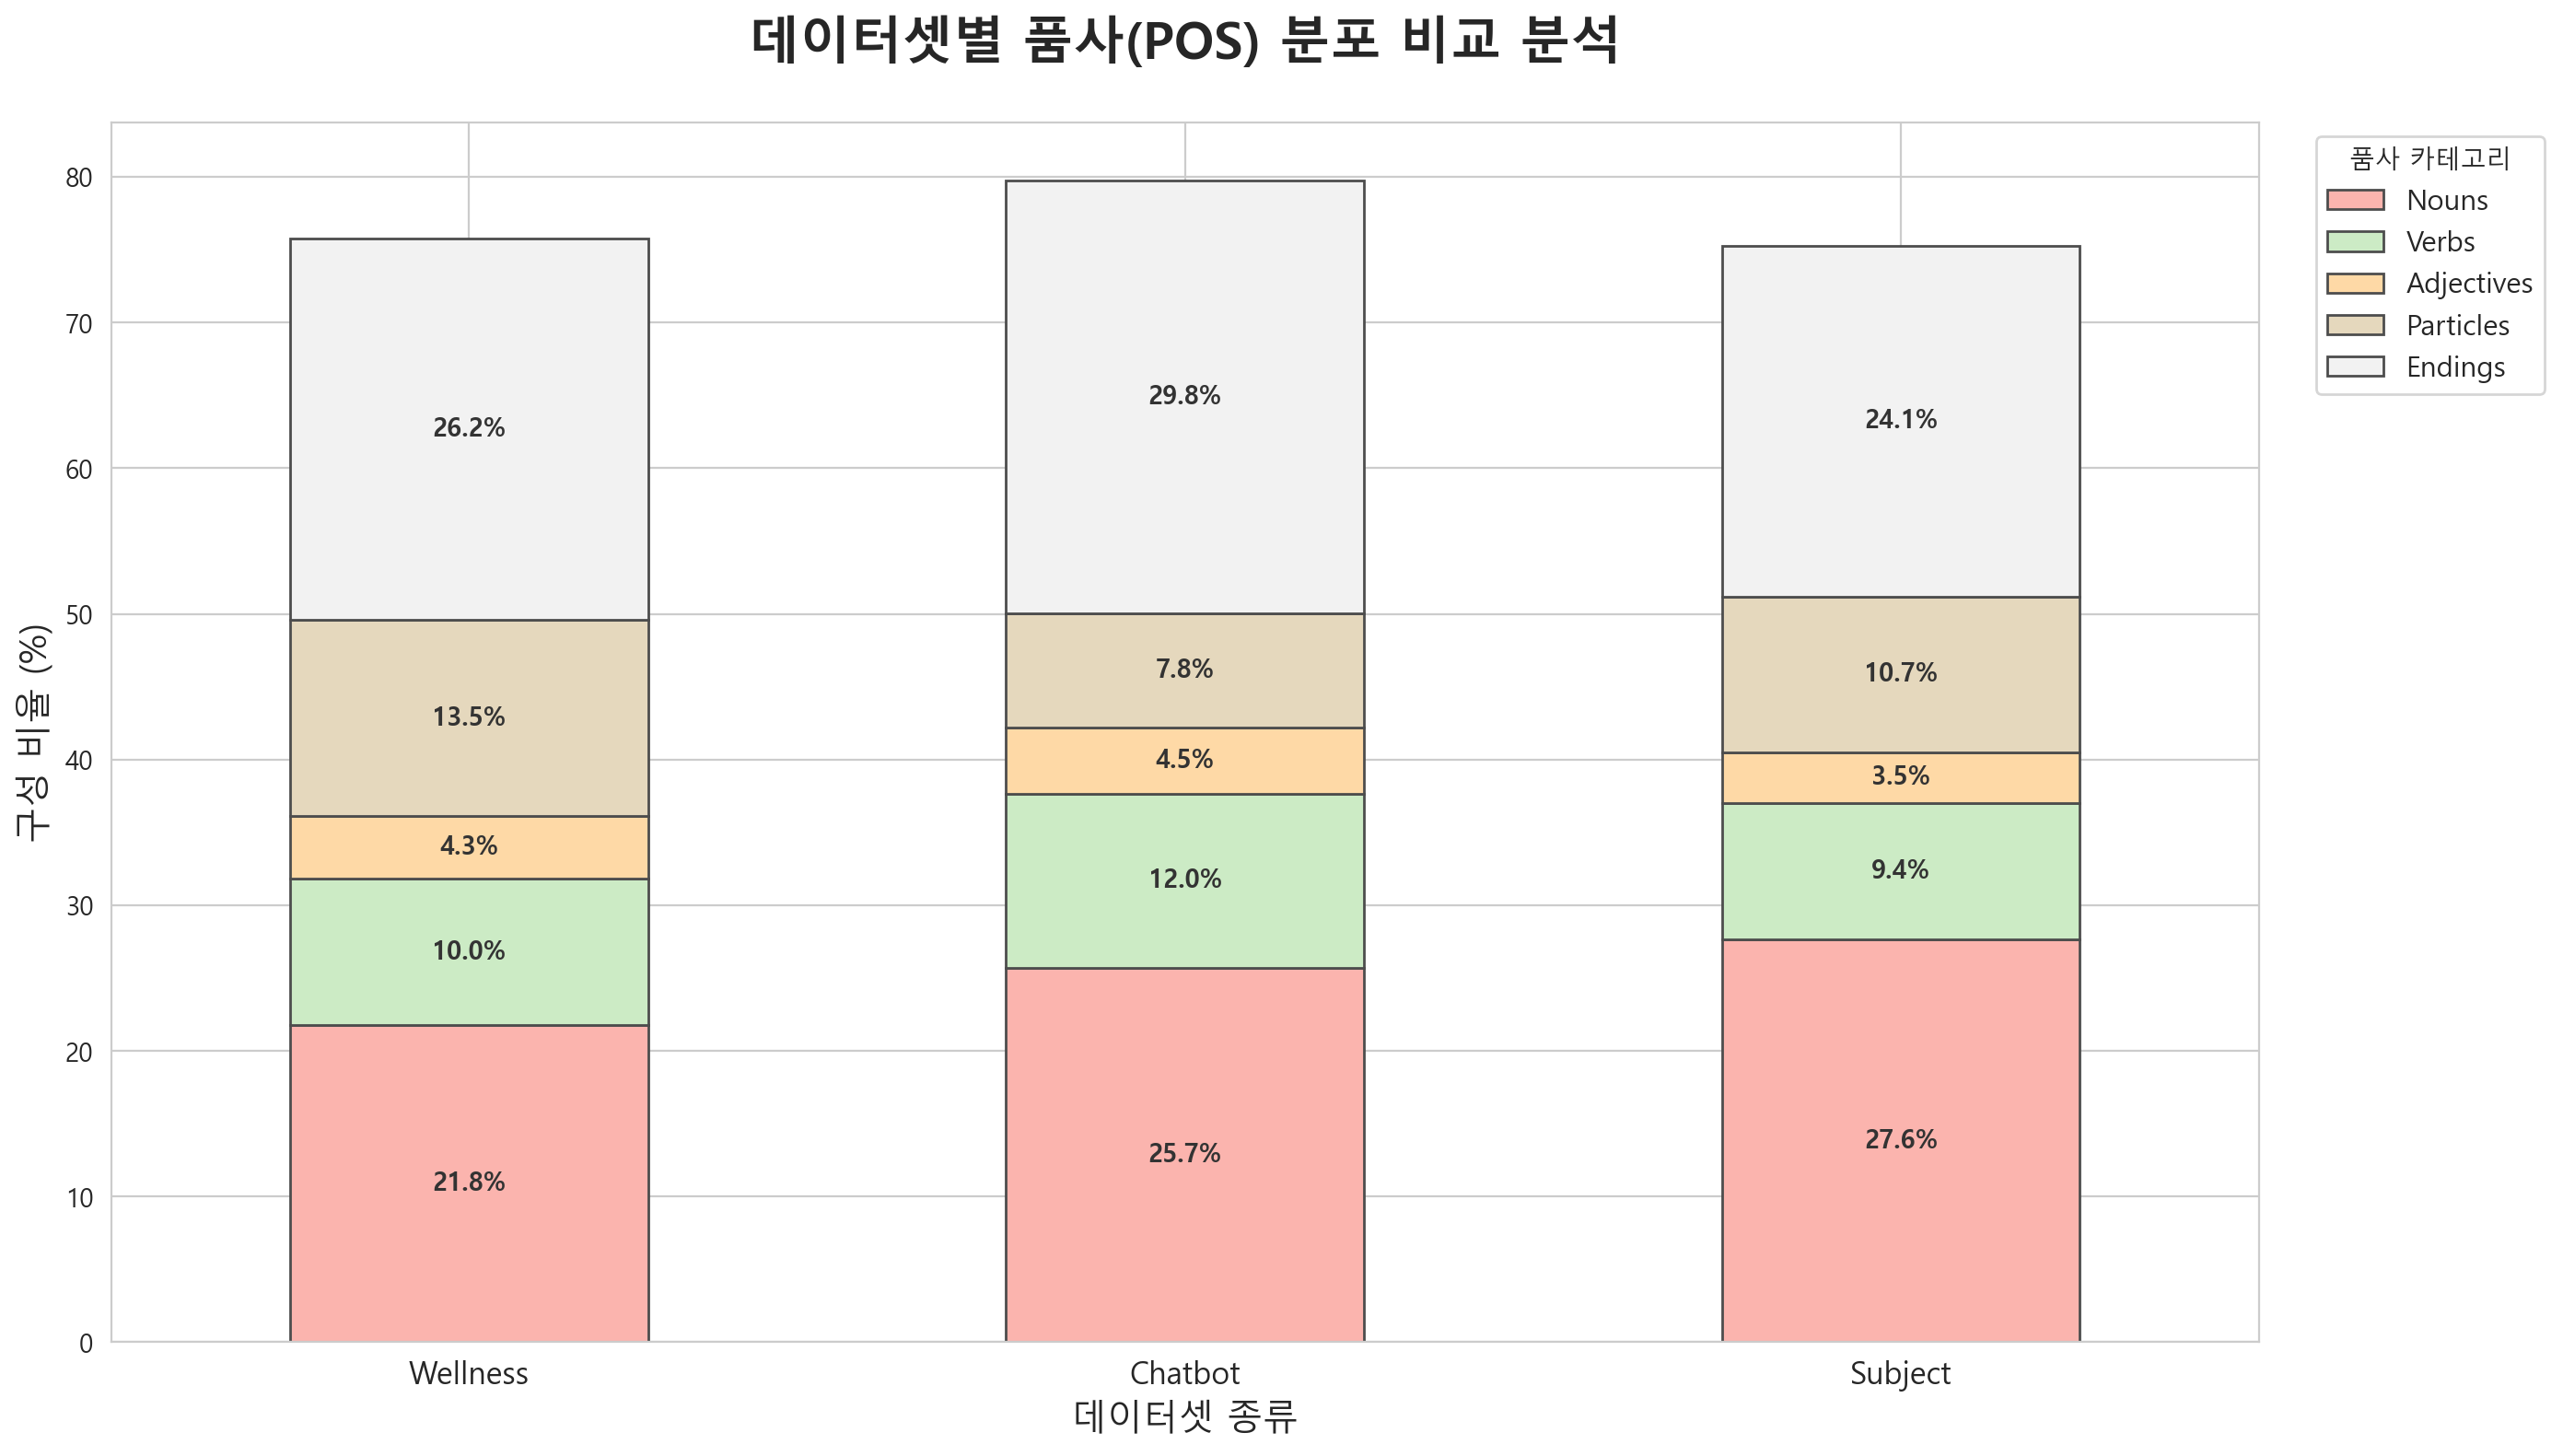

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from kiwipiepy import Kiwi
from collections import Counter

# ==========================================
# 1. 한글 폰트 깨짐 해결 (윈도우 데스크탑 전용)
# ==========================================
# Seaborn 스타일을 먼저 설정해야 폰트 설정이 초기화되지 않습니다.
sns.set_style("whitegrid")

# 맑은 고딕 전체 경로 지정
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

# Matplotlib 전역 폰트 설정 적용
plt.rc('font', family=font_name)
plt.rcParams['font.family'] = font_name
plt.rc('axes', unicode_minus=False)  # 마이너스 기호 깨짐 방지

# 고해상도 설정
%config InlineBackend.figure_format = 'retina'

print(f"시스템 폰트 설정 완료: {font_name}")

# ==========================================
# 2. Kiwi 초기화 및 데이터 로드
# ==========================================
kiwi = Kiwi()
files = {
    "Wellness": "cleaned_wellness.csv",
    "Chatbot": "cleaned_chatbot.csv",
    "Subject": "cleaned_subject.csv"
}

def analyze_pos_ratio_fixed(df, name, column_name='utterance'):
    # 데이터를 리스트로 변환하고 결측치 제거
    sentences = df[column_name].dropna().astype(str).tolist()
    pos_counts = Counter()
    total_tokens = 0

    print(f"[{name}] 데이터 분석 중... 잠시만 기다려주세요.")

    # 문장별로 형태소 분석 수행 (모든 Kiwi 버전 호환)
    for sent in sentences:
        if not sent.strip(): continue
        
        result = kiwi.analyze(sent)
        
        # result[0][0]은 가장 확률이 높은 분석 결과의 토큰 리스트
        for token in result[0][0]:
            tag = token.tag
            total_tokens += 1
            
            # 품사 카테고리 분류 (주요 5대 품사 기준)
            if tag.startswith('N'): # 명사 (일반, 고유, 대명사 등)
                pos_counts['Nouns'] += 1
            elif tag == 'VV': # 동사
                pos_counts['Verbs'] += 1
            elif tag == 'VA': # 형용사
                pos_counts['Adjectives'] += 1
            elif tag.startswith('J'): # 조사
                pos_counts['Particles'] += 1
            elif tag.startswith('E'): # 어미
                pos_counts['Endings'] += 1
            else:
                pos_counts['Others'] += 1

    # 비율(%) 계산
    if total_tokens == 0: return None
    ratios = {category: (count / total_tokens) * 100 for category, count in pos_counts.items()}
    ratios['Dataset'] = name
    return ratios

# ==========================================
# 3. 분석 실행 및 데이터 정리
# ==========================================
all_ratios = []
for name, file in files.items():
    try:
        df = pd.read_csv(file)
        res = analyze_pos_ratio_fixed(df, name)
        if res: all_ratios.append(res)
    except Exception as e:
        print(f"{name} 파일 처리 중 오류 발생: {e}")

# 결과 데이터프레임 생성 및 순서 정렬
ratio_df = pd.DataFrame(all_ratios).set_index('Dataset')
plot_df = ratio_df[['Nouns', 'Verbs', 'Adjectives', 'Particles', 'Endings']]

# ==========================================
# 4. 시각화 (Stacked Bar Chart)
# ==========================================
fig, ax = plt.subplots(figsize=(14, 8))

# 누적 막대 그래프 그리기
plot_df.plot(kind='bar', stacked=True, ax=ax, colormap='Pastel1', edgecolor='0.3')

# 그래프 제목 및 라벨 설정 (한글 확인 필수)
ax.set_title('데이터셋별 품사(POS) 분포 비교 분석', fontsize=20, pad=25, fontweight='bold')
ax.set_ylabel('구성 비율 (%)', fontsize=14)
ax.set_xlabel('데이터셋 종류', fontsize=14)
ax.set_xticklabels(plot_df.index, rotation=0, fontsize=12)

# 범례 설정
ax.legend(title='품사 카테고리', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

# 막대 내부 수치(%) 표시
for p in ax.patches:
    h = p.get_height()
    if h > 3: # 비율이 3% 이상인 경우에만 텍스트 표시
        ax.text(p.get_x() + p.get_width()/2., 
                p.get_y() + h/2., 
                f'{h:.1f}%', 
                ha='center', 
                va='center', 
                fontsize=10, 
                fontweight='bold',
                color='#333333')

plt.tight_layout()
plt.show()